In [136]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE YOUR PARAMETERS
# ==========================================
# Geometry & Properties
L_skin   = 0.003    # Thickness of skin/fat layer [m] (e.g. 5mm)
k_skin   = 0.3      # Thermal conductivity of skin [W/m*K]
q        = 100      # Metabolic heat generation [W]
A        = 1.8      # m^2 surface area of skin.
k_suit   = 0.014     # Insulation conductivity [W/m*K]
hAir     = 2        # Convection coefficient [W/m^2*K]
h_rAir   = 5.9      # W/m^2*K
hWater   = 200      # Convection coefficient [W/m^2*K]
h_rWater = 0

# Boundary Conditions
T_i      = 35.0     # Inner body temperature [C]
T_inf    = 10.0     # Ambient fluid temperature [C]



In [137]:


#finding L_suit in water



h_combWater    = h_rWater+hWater 
R_totq    = (T_i - T_inf) / (q)
L_suitWater    = k_suit * (A*R_totq - (L_skin) / (k_skin) - 1 / (h_combWater))

print(f"Calculated L_suitWater : {L_suitWater:.4f}")
print(f"Calculated R_totq : {R_totq:.4f}")

Calculated L_suitWater : 0.0061
Calculated R_totq : 0.2500


In [138]:
#finding L_suit in air

h_combAir    = h_rAir+hAir 
R_totq    = (T_i - T_inf) / (q)
L_suitAir    = k_suit * (A*R_totq - (L_skin) / (k_skin) - 1 / (h_combAir))

print(f"Calculated L_suitAir : {L_suitAir:.4f}")
print(f"Calculated R_totq : {R_totq:.4f}")

Calculated L_suitAir : 0.0044
Calculated R_totq : 0.2500


In [147]:
# ==========================================
# The "Handshake Air
# ==========================================
# C1 is easy (Boundary Condition at x=0)
C1 = T_i

q_dot = q / A * L_skin

R_totThermalAir = (1/A)* ((L_suitAir / k_suit)+1/(h_combAir)) 

# C0 is the complex algebraic solution we derived
# Numerator terms
term1 = R_tot * q_dot * L_skin
term2 = (q_dot / (2 * k_skin)) * L_skin**2
term3 = T_inf - T_i

# Denominator terms
denom = (L_skin / k_skin) + R_tot

# Calculate C0
C0Air = (term1 + term2 + term3) / denom



In [148]:
# ==========================================
# The "Handshake" Water
# ==========================================
# C1 is easy (Boundary Condition at x=0)
C1 = T_i

q_dot = q / A * L_skin

R_totThermalWater = (1/A)* ((L_suitWater / k_suit)+1/(h_combWater)) 

# C0 is the complex algebraic solution we derived
# Numerator terms
term1 = R_tot * q_dot * L_skin
term2 = (q_dot / (2 * k_skin)) * L_skin**2
term3 = T_inf - T_i

# Denominator terms
denom = (L_skin / k_skin) + R_tot

# Calculate C0
C0Water = (term1 + term2 + term3) / denom


In [149]:
print(f"Calculated C0Air (Flux Constant): {C0Air:.4f}")
print(f"Calculated C1 (i Temp): {C1:.4f}")

# ==========================================
# 3. CALCULATE TEMPERATURE DISTRIBUTION Air
# ==========================================
# Create an array of x positions from 0 to L_skin
x = np.linspace(0, L_skin, 100)

# The Temperature Equation: T(x) = -q_dot/2k * x^2 + (C0/k)*x + C1
T_distAir = -(q_dot / (2 * k_skin)) * x**2 + (C0 / k_skin) * x + C1

# Calculate the specific surface temperature at x = L_skin
T_surfaceAir = T_dist[-1]
print(f"Surface Temperature (Skin/Insulation Interface using air): {T_surfaceAir:.2f} C")



Calculated C0Air (Flux Constant): -69.4440
Calculated C1 (i Temp): 35.0000
Surface Temperature (Skin/Insulation Interface using air): 34.78 C


In [150]:
print(f"Calculated C0Water (Flux Constant): {C0:.4f}")
print(f"Calculated C1 (i Temp): {C1:.4f}")

# ==========================================
# 3. CALCULATE TEMPERATURE DISTRIBUTION water
# ==========================================
# Create an array of x positions from 0 to L_skin
x = np.linspace(0, L_skin, 100)

# The Temperature Equation: T(x) = -q_dot/2k * x^2 + (C0/k)*x + C1
T_distWater = -(q_dot / (2 * k_skin)) * x**2 + (C0 / k_skin) * x + C1

# Calculate the specific surface temperature at x = L_skin
T_surfaceWater = T_dist[-1]
print(f"Surface Temperature (Skin/Insulation Interface uaing water): {T_surfaceWater:.2f} C")


Calculated C0Water (Flux Constant): -22.2305
Calculated C1 (i Temp): 35.0000
Surface Temperature (Skin/Insulation Interface uaing water): 34.78 C


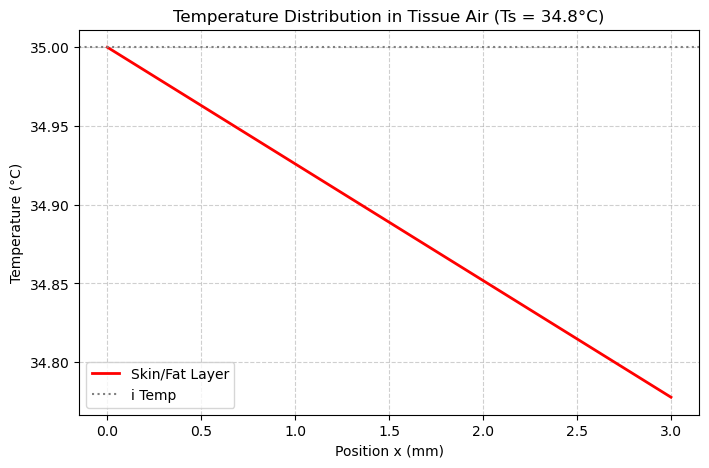

In [151]:
# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(x * 1000, T_dist, label='Skin/Fat Layer', color='red', linewidth=2)

# Formatting
plt.xlabel('Position x (mm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Distribution in Tissue Air (Ts = {T_surfaceAir:.1f}°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(T_i, color='gray', linestyle=':', label='i Temp')
plt.legend()

plt.show()

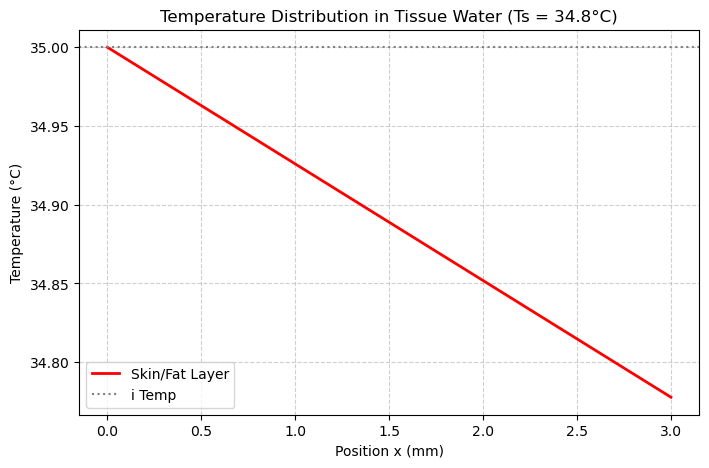

In [152]:
# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(x * 1000, T_dist, label='Skin/Fat Layer', color='red', linewidth=2)

# Formatting
plt.xlabel('Position x (mm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Distribution in Tissue Water (Ts = {T_surfaceWater:.1f}°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(T_i, color='gray', linestyle=':', label='i Temp')
plt.legend()

plt.show()

Found existing C0 calculations.


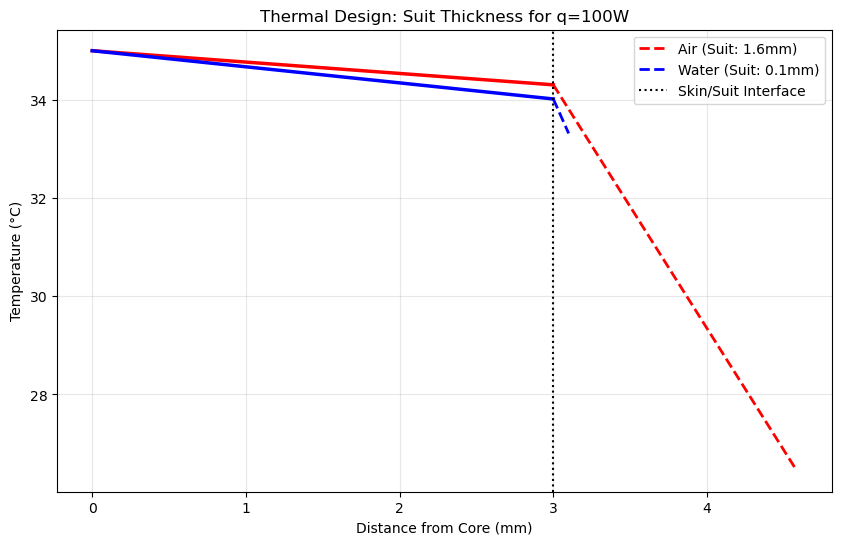

In [153]:
# ==========================================
# PLOTTING ROUTINE (Run this after calculations)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# --- SAFETY BRIDGE: Link your calc variables to the plotter ---
# We assume you have calculated 'C0Air' and 'C0Water' in previous blocks.
# If not, we re-calculate them here to prevent the crash.

try:
    # Try to grab the variables from your previous cells
    C0_plot_air   = C0Air
    C0_plot_water = C0Water
    print("Found existing C0 calculations.")
except NameError:
    print("Could not find C0Air/C0Water. Recalculating them now...")
    # Quick Recalculate if they are missing
    # AIR
    h_comb_air = hAir + h_rAir # Using your variables
    R_prime_A  = (L_suitA / k_suit) + (1 / h_comb_air)
    C0_plot_air = (R_prime_A * q_dot * L_skin + (q_dot/(2*k_skin))*L_skin**2 + (T_inf - T_i)) / ((L_skin/k_skin) + R_prime_A)
    
    # WATER
    h_comb_water = hWater + h_rWater
    R_prime_W  = (L_suitW / k_suit) + (1 / h_comb_water)
    C0_plot_water = (R_prime_W * q_dot * L_skin + (q_dot/(2*k_skin))*L_skin**2 + (T_inf - T_i)) / ((L_skin/k_skin) + R_prime_W)

# ==========================================
# THE PLOT LOGIC
# ==========================================
plt.figure(figsize=(10, 6))

# Helper function
def plot_full_stack(L_suit_val, C0_val, color, label_text):
    # 1. SKIN (Parabola)
    x_skin = np.linspace(0, L_skin, 50)
    # T(x) = -q/2k*x^2 + C0/k*x + C1
    T_skin = -(q_dot / (2 * k_skin)) * x_skin**2 + (C0_val / k_skin) * x_skin + T_i
    
    T_interface = T_skin[-1]
    
    # 2. SUIT (Linear)
    x_suit = np.linspace(L_skin, L_skin + L_suit_val, 50)
    
    # Calculate outer temp based on flux continuity
    # Flux leaving skin = (T_interface - T_outer) / (L_suit / k_suit)
    # Flux is also approx (q_dot*L - C0)
    flux_approx = q_dot * L_skin - C0_val
    T_outer = T_interface - (flux_approx * L_suit_val / k_suit)
    
    T_suit = np.linspace(T_interface, T_outer, 50)
    
    # Plot
    plt.plot(x_skin * 1000, T_skin, color=color, linewidth=2.5) 
    plt.plot(x_suit * 1000, T_suit, color=color, linestyle='--', linewidth=2, label=label_text)

# Plot Air (Red)
plot_full_stack(L_suitA, C0_plot_air, 'red', f'Air (Suit: {L_suitA*1000:.1f}mm)')

# Plot Water (Blue)
plot_full_stack(L_suitW, C0_plot_water, 'blue', f'Water (Suit: {L_suitW*1000:.1f}mm)')

# Formatting
plt.axvline(L_skin * 1000, color='black', linestyle=':', label='Skin/Suit Interface')
plt.xlabel('Distance from Core (mm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Thermal Design: Suit Thickness for q={q}W')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

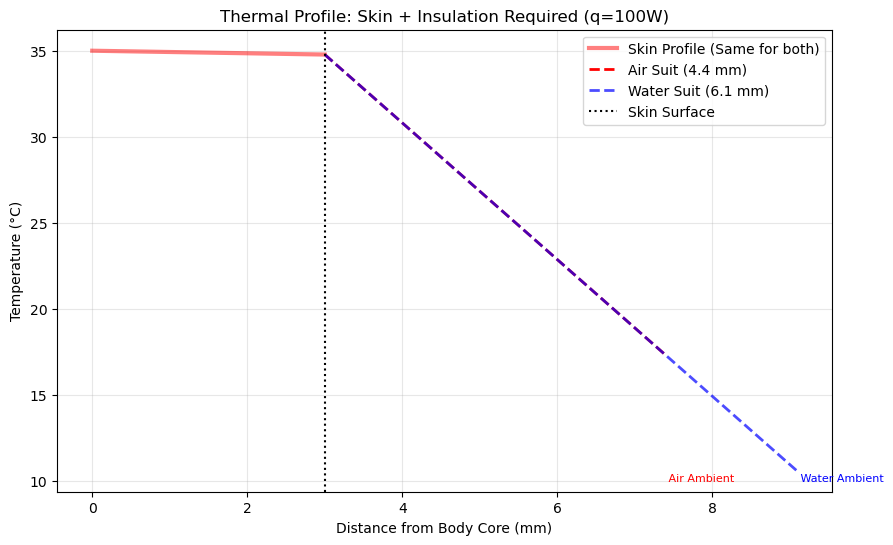

In [154]:
# ==========================================
# FINAL COMPARISON PLOT (Skin + Suit)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. SETUP DATA
# Convert x skin to mm
x_skin_mm = x * 1000

# Calculate Heat Flux (W/m^2) flowing through the system
# This determines the slope of the temperature drop in the suit
flux = q / A 

# ==============================
# 2. CREATE SUIT PROFILES
# ==============================
# The suit creates a linear temperature drop: T = T_surf - (Flux * distance / k)

# --- Air Case ---
# Create x points for the suit (from L_skin to L_skin + L_suitAir)
x_suit_air = np.linspace(L_skin, L_skin + L_suitAir, 50)
# Calculate Temp profile
T_suit_air = T_surfaceAir - (flux * (x_suit_air - L_skin) / k_suit)

# --- Water Case ---
# Create x points for the suit
x_suit_water = np.linspace(L_skin, L_skin + L_suitWater, 50)
# Calculate Temp profile
T_suit_water = T_surfaceWater - (flux * (x_suit_water - L_skin) / k_suit)

# ==============================
# 3. PLOTTING
# ==============================

# --- Plot Skin (Solid Lines) ---
# Note: They will overlap perfectly, so we use transparency or just plot one clearly
plt.plot(x_skin_mm, T_distAir, 'r-', linewidth=3, alpha=0.5, label='Skin Profile (Same for both)')

# --- Plot Suits (Dashed Lines) ---
# Air Suit (Red Dashed)
plt.plot(x_suit_air * 1000, T_suit_air, 'r--', linewidth=2, label=f'Air Suit ({L_suitAir*1000:.1f} mm)')

# Water Suit (Blue Dashed)
plt.plot(x_suit_water * 1000, T_suit_water, 'b--', linewidth=2,alpha=0.7, label=f'Water Suit ({L_suitWater*1000:.1f} mm)')

# --- Visualizing the Interface ---
plt.axvline(L_skin * 1000, color='black', linestyle=':', label='Skin Surface')

# --- Formatting ---
plt.xlabel('Distance from Body Core (mm)')
plt.ylabel('Temperature (°C)')
plt.title(f'Thermal Profile: Skin + Insulation Required (q={q}W)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add text to show where the fluid starts
plt.text((L_skin + L_suitAir)*1000, T_inf, ' Air Ambient', color='red', fontsize=8)
plt.text((L_skin + L_suitWater)*1000, T_inf, ' Water Ambient', color='blue', fontsize=8)

plt.show()